<a href="https://colab.research.google.com/github/rehmanzainab2404/AI-project-1/blob/main/smart_park.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_DIR = "/content/drive/MyDrive/smartpark"
os.makedirs(f"{BASE_DIR}/data/raw", exist_ok=True)
os.makedirs(f"{BASE_DIR}/data/processed/occupied", exist_ok=True)
os.makedirs(f"{BASE_DIR}/data/processed/vacant", exist_ok=True)
os.makedirs(f"{BASE_DIR}/models", exist_ok=True)
os.makedirs(f"{BASE_DIR}/results", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs/sample_images", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs/cv_baseline", exist_ok=True)
os.chdir(BASE_DIR)
print("Working directory set to:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory set to: /content/drive/MyDrive/smartpark


In [3]:
pip install -q fiftyone huggingface_hub scikit-image seaborn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.2/268.2 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 109.4 MB/s eta 0

In [8]:
from huggingface_hub import login

login()

In [10]:
!pip uninstall -y pillow fiftyone
!pip install -q "pillow==10.4.0" "fiftyone==0.25.0" "huggingface_hub==0.25.0"

Found existing installation: pillow 12.3.0
Uninstalling pillow-12.3.0:
  Successfully uninstalled pillow-12.3.0
Found existing installation: fiftyone 1.22.1
Uninstalling fiftyone-1.22.1:
  Successfully uninstalled fiftyone-1.22.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.4/436.4 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.5/192.5 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.1/98.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 942.7/942.7 kB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently tak

In [11]:
!pip uninstall -y fiftyone pillow huggingface_hub
!pip install -q "pillow>=10.4,<12" "huggingface_hub>=1.5,<2" "fiftyone==0.25.0"

Found existing installation: fiftyone 0.25.0
Uninstalling fiftyone-0.25.0:
  Successfully uninstalled fiftyone-0.25.0
Found existing installation: pillow 10.4.0
Uninstalling pillow-10.4.0:
  Successfully uninstalled pillow-10.4.0
Found existing installation: huggingface-hub 0.25.0
Uninstalling huggingface-hub-0.25.0:
  Successfully uninstalled huggingface-hub-0.25.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 40.0 MB/s eta 0:00:00


In [2]:
!pip uninstall -y fiftyone mongoengine pymongo

Found existing installation: fiftyone 0.25.0
Uninstalling fiftyone-0.25.0:
  Successfully uninstalled fiftyone-0.25.0
Found existing installation: mongoengine 0.24.2
Uninstalling mongoengine-0.24.2:
  Successfully uninstalled mongoengine-0.24.2
Found existing installation: pymongo 4.9.2
Uninstalling pymongo-4.9.2:
  Successfully uninstalled pymongo-4.9.2


In [2]:
!pip install -q -U "huggingface_hub>=1.5,<2"


In [3]:
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(
    repo_id="Voxel51/PKLot",
    repo_type="dataset"
)

print("PKLot downloaded to:")
print(dataset_path)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12423 files:   0%|          | 0/12423 [00:00<?, ?it/s]

PKLot downloaded to:
/root/.cache/huggingface/hub/datasets--Voxel51--PKLot/snapshots/17654327c54c4b6e551606ffa99a8999fea9f42b


In [5]:
from huggingface_hub import login

login()

In [6]:
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(
    repo_id="Voxel51/PKLot",
    repo_type="dataset"
)

print("PKLot downloaded to:")
print(dataset_path)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12423 files:   0%|          | 0/12423 [00:00<?, ?it/s]

PKLot downloaded to:
/root/.cache/huggingface/hub/datasets--Voxel51--PKLot/snapshots/17654327c54c4b6e551606ffa99a8999fea9f42b


In [7]:
import os

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  {file}")

    if level >= 2:
        dirs[:] = []

17654327c54c4b6e551606ffa99a8999fea9f42b/
  metadata.json
  pklot-mq.gif
  .gitattributes
  parse_pklot_to_fiftyone.py
  samples.json
  README.md
  fiftyone.yml
  data/
    data_0/
      2012-10-15_14_26_02.jpg
      2012-09-17_13_54_10.jpg
      2012-10-30_16_12_21.jpg
      2012-09-18_16_35_15.jpg
      2012-09-20_06_49_15.jpg
      2012-09-17_14_24_11.jpg
      2012-09-18_09_44_57.jpg
      2012-09-17_16_49_17.jpg
      2012-09-20_14_59_37.jpg
      2012-09-17_11_04_02.jpg
    data_2/
      2012-10-13_10_08_44.jpg
      2012-10-16_11_03_34.jpg
      2012-09-28_15_16_22.jpg
      2012-10-12_09_17_38.jpg
      2012-10-16_18_23_56.jpg
      2012-10-14_12_29_52.jpg
      2012-10-27_07_00_36.jpg
      2012-10-27_08_00_39.jpg
      2012-10-12_10_47_42.jpg
      2012-10-14_16_40_03.jpg
    data_12/
      2013-04-13_06_55_01.jpg
      2013-03-13_16_45_12.jpg
      2013-04-12_17_45_13.jpg
      2013-04-13_07_15_01.jpg
      2013-04-13_08_15_02.jpg
      2013-03-09_13_00_08.jpg
      2013-03-

In [9]:
!pip install -q -U "huggingface_hub>=1.5,<2"

In [10]:
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(
    repo_id="Voxel51/PKLot",
    repo_type="dataset"
)

print("Dataset path:")
print(dataset_path)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12423 files:   0%|          | 0/12423 [00:00<?, ?it/s]

Dataset path:
/root/.cache/huggingface/hub/datasets--Voxel51--PKLot/snapshots/17654327c54c4b6e551606ffa99a8999fea9f42b


In [11]:
import cv2
import os
import glob
import matplotlib.pyplot as plt

# Create output folders
os.makedirs("outputs/sample_images", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Find image files inside PKLot
extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]

image_paths = []

for ext in extensions:
    image_paths.extend(
        glob.glob(
            os.path.join(dataset_path, "**", ext),
            recursive=True
        )
    )

print(f"Total image files found: {len(image_paths)}")

# Check image dimensions
widths = []
heights = []
corrupted = []

for filepath in image_paths:

    img = cv2.imread(filepath)

    if img is None:
        corrupted.append(filepath)
        continue

    h, w = img.shape[:2]

    widths.append(w)
    heights.append(h)

print(f"\nCorrupted/unreadable images: {len(corrupted)}")

if widths:
    print(
        f"Width  -> min {min(widths)}, "
        f"max {max(widths)}, "
        f"most common {max(set(widths), key=widths.count)}"
    )

    print(
        f"Height -> min {min(heights)}, "
        f"max {max(heights)}, "
        f"most common {max(set(heights), key=heights.count)}"
    )

Total image files found: 12416

Corrupted/unreadable images: 0
Width  -> min 1280, max 1280, most common 1280
Height -> min 720, max 720, most common 720


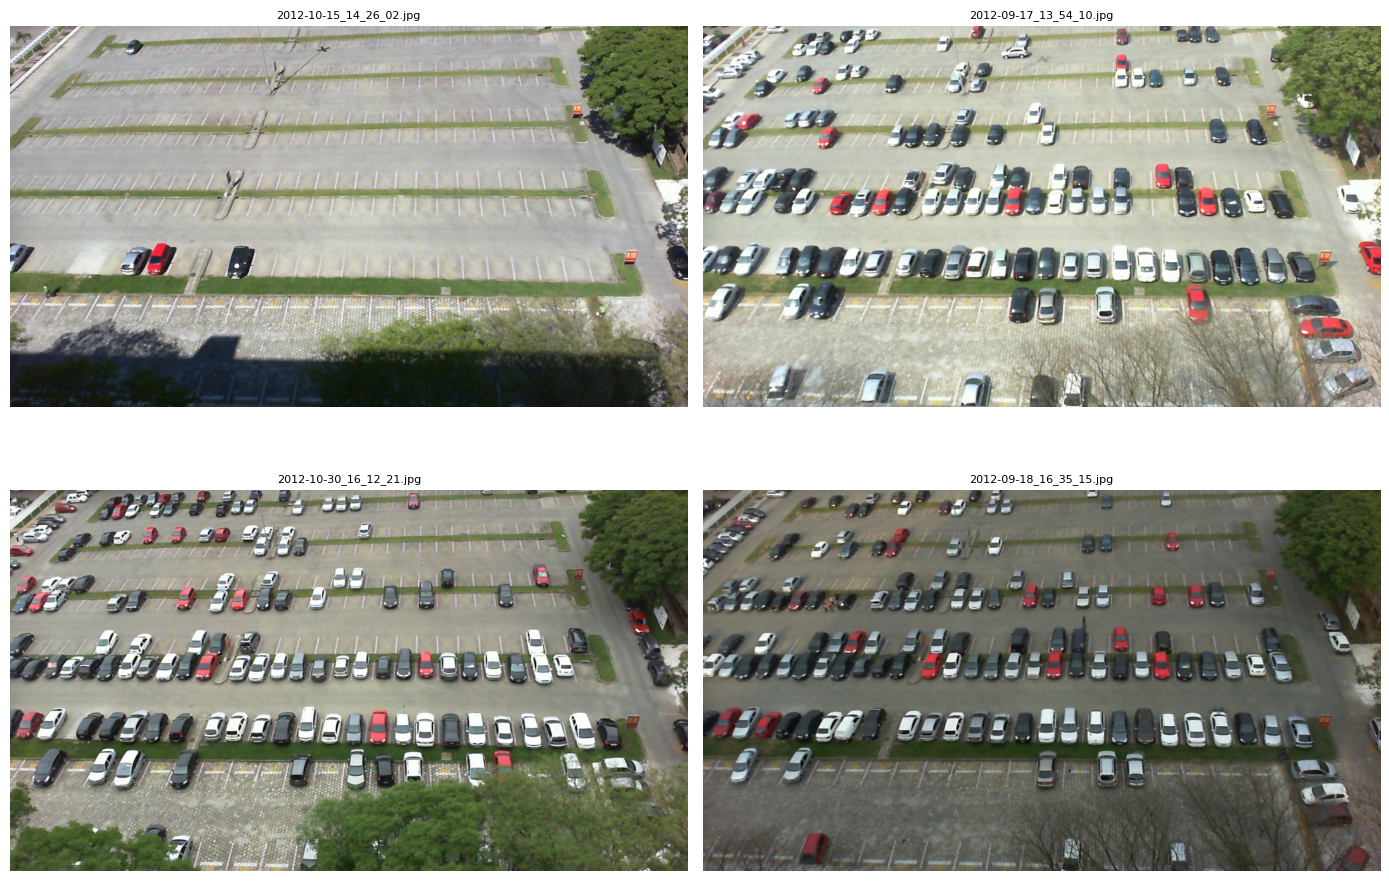

Saved:
results/sample_grid.png
outputs/sample_images/


In [12]:
plt.figure(figsize=(14, 10))

sample_paths = image_paths[:4]

for i, filepath in enumerate(sample_paths):

    img = cv2.imread(filepath)

    if img is None:
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img_rgb)
    plt.title(os.path.basename(filepath), fontsize=8)
    plt.axis("off")

    # Save individual image
    cv2.imwrite(
        f"outputs/sample_images/sample_{i}.jpg",
        img
    )

plt.tight_layout()

plt.savefig(
    "results/sample_grid.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("results/sample_grid.png")
print("outputs/sample_images/")

In [13]:
import os

print("PKLot path:")
print(dataset_path)

print("\nTop-level contents:")

for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)

    if os.path.isdir(full_path):
        print(f"[DIR]  {item}")
    else:
        print(f"[FILE] {item}")

PKLot path:
/root/.cache/huggingface/hub/datasets--Voxel51--PKLot/snapshots/17654327c54c4b6e551606ffa99a8999fea9f42b

Top-level contents:
[FILE] metadata.json
[FILE] pklot-mq.gif
[FILE] .gitattributes
[FILE] parse_pklot_to_fiftyone.py
[DIR]  data
[FILE] samples.json
[FILE] README.md
[FILE] fiftyone.yml


In [14]:
import os

annotation_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        lower = file.lower()

        if lower.endswith((
            ".json",
            ".xml",
            ".csv",
            ".txt",
            ".yaml",
            ".yml"
        )):
            annotation_files.append(
                os.path.join(root, file)
            )

print(f"Annotation/metadata files found: {len(annotation_files)}")

for path in annotation_files[:30]:
    print(path)

Annotation/metadata files found: 3
/root/.cache/huggingface/hub/datasets--Voxel51--PKLot/snapshots/17654327c54c4b6e551606ffa99a8999fea9f42b/metadata.json
/root/.cache/huggingface/hub/datasets--Voxel51--PKLot/snapshots/17654327c54c4b6e551606ffa99a8999fea9f42b/samples.json
/root/.cache/huggingface/hub/datasets--Voxel51--PKLot/snapshots/17654327c54c4b6e551606ffa99a8999fea9f42b/fiftyone.yml


In [15]:
import json
import os

samples_file = os.path.join(dataset_path, "samples.json")

with open(samples_file, "r", encoding="utf-8") as f:
    samples_data = json.load(f)

print("Type:", type(samples_data))

if isinstance(samples_data, dict):
    print("\nTop-level keys:")
    print(samples_data.keys())

    for key, value in samples_data.items():
        print(f"\nKEY: {key}")
        print("TYPE:", type(value))

        if isinstance(value, list):
            print("Number of items:", len(value))
            if len(value) > 0:
                print("\nFirst item:")
                print(json.dumps(value[0], indent=2)[:5000])

        elif isinstance(value, dict):
            print("Keys:", list(value.keys())[:30])

elif isinstance(samples_data, list):
    print("Number of samples:", len(samples_data))

    if len(samples_data) > 0:
        print("\nFirst sample:")
        print(json.dumps(samples_data[0], indent=2)[:5000])

Type: <class 'dict'>

Top-level keys:
dict_keys(['samples'])

KEY: samples
TYPE: <class 'list'>
Number of items: 12416

First item:
{
  "_id": {
    "$oid": "68c1a702aaceeb2f790f446a"
  },
  "filepath": "data/data_0/2012-09-21_14_45_32.jpg",
  "tags": [],
  "_media_type": "image",
  "_rand": 0.9998206599513502,
  "source": "pucpr",
  "weather": {
    "_id": {
      "$oid": "68c1a690aaceeb2f790419a6"
    },
    "_cls": "Classification",
    "tags": [],
    "label": "sunny"
  },
  "date": {
    "$date": "2012-09-21T00:00:00Z"
  },
  "parking_timestamp": {
    "$date": "2012-09-21T14:45:32Z"
  },
  "parking_spaces": {
    "_cls": "Polylines",
    "polylines": [
      {
        "_id": {
          "$oid": "68c1a690aaceeb2f79041942"
        },
        "_cls": "Polyline",
        "attributes": {},
        "tags": [],
        "label": "parking_space",
        "points": [
          [
            [
              0.2171875,
              0.3194444444444444
            ],
            [
           

In [16]:
import os
import json
import csv
import cv2
import numpy as np

from sklearn.model_selection import train_test_split

# =========================
# SETTINGS
# =========================

PATCH_SIZE = 64

OUTPUT_DIR = "data/processed"

os.makedirs(f"{OUTPUT_DIR}/occupied", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/vacant", exist_ok=True)

# =========================
# LOAD SAMPLES.JSON
# =========================

samples_file = os.path.join(dataset_path, "samples.json")

with open(samples_file, "r", encoding="utf-8") as f:
    samples_data = json.load(f)

print("samples.json loaded successfully.")
print("Type:", type(samples_data))


# =========================
# FIND SAMPLE LIST
# =========================

if isinstance(samples_data, list):
    samples = samples_data

elif isinstance(samples_data, dict):

    if "samples" in samples_data:
        samples = samples_data["samples"]

    else:
        # Find the first list that looks like samples
        samples = None

        for key, value in samples_data.items():
            if isinstance(value, list):
                samples = value
                print("Using list under key:", key)
                break

        if samples is None:
            raise ValueError("Could not find sample list in samples.json.")

else:
    raise ValueError("Unexpected samples.json format.")

print("Number of samples:", len(samples))


# =========================
# HELPER: FIND IMAGE
# =========================

def find_image_file(filepath):

    # If path is already absolute and exists
    if filepath and os.path.exists(filepath):
        return filepath

    # Try path relative to dataset
    if filepath:
        candidate = os.path.join(dataset_path, filepath)

        if os.path.exists(candidate):
            return candidate

        # Sometimes paths contain ./
        candidate = os.path.join(
            dataset_path,
            filepath.replace("./", "", 1)
        )

        if os.path.exists(candidate):
            return candidate

    # Fallback: search by filename
    if filepath:
        filename = os.path.basename(filepath)

        for root, dirs, files in os.walk(dataset_path):
            if filename in files:
                return os.path.join(root, filename)

    return None


# =========================
# EXTRACT PARKING SPACES
# =========================

records = []

saved_count = {
    "occupied": 0,
    "vacant": 0
}

skipped = 0


for sample_index, sample in enumerate(samples):

    # --------------------------------
    # Get image filepath
    # --------------------------------

    filepath = (
        sample.get("filepath")
        or sample.get("file_path")
        or sample.get("path")
    )

    image_path = find_image_file(filepath)

    if image_path is None:
        skipped += 1
        continue

    img = cv2.imread(image_path)

    if img is None:
        skipped += 1
        continue

    h_img, w_img = img.shape[:2]

    # --------------------------------
    # Find parking-space annotations
    # --------------------------------

    annotations = (
        sample.get("ground_truth")
        or sample.get("detections")
        or sample.get("polylines")
    )

    if annotations is None:
        skipped += 1
        continue

    # If annotations is a dictionary
    if isinstance(annotations, dict):

        # Common FiftyOne format
        if "polylines" in annotations:
            annotations = annotations["polylines"]

        elif "detections" in annotations:
            annotations = annotations["detections"]

        elif "polylines" in annotations.get("polylines", {}):
            annotations = annotations["polylines"]

    if not isinstance(annotations, list):
        skipped += 1
        continue


    # --------------------------------
    # Process every parking space
    # --------------------------------

    for j, annotation in enumerate(annotations):

        if not isinstance(annotation, dict):
            continue

        # We only want parking-space annotations
        label = str(
            annotation.get("label", "")
        ).lower().strip()

        if label != "parking_space":
            continue

        # Get occupancy
        occupancy = str(
            annotation.get("occupancy_status", "")
        ).lower().strip()

        if occupancy in ["occupied", "busy", "1"]:
            class_name = "occupied"

        elif occupancy in ["vacant", "empty", "free", "0"]:
            class_name = "vacant"

        else:
            continue


        # --------------------------------
        # Get polygon points
        # --------------------------------

        points = annotation.get("points")

        if not points:
            continue

        # Usually:
        # points = [
        #   [
        #       [x1,y1],
        #       [x2,y2],
        #       ...
        #   ]
        # ]

        polygon = points[0]

        if len(polygon) < 3:
            continue


        # --------------------------------
        # Convert normalized coordinates
        # to pixel coordinates
        # --------------------------------

        pixel_points = []

        for point in polygon:

            x_norm = float(point[0])
            y_norm = float(point[1])

            x_pixel = int(x_norm * w_img)
            y_pixel = int(y_norm * h_img)

            pixel_points.append(
                [x_pixel, y_pixel]
            )

        pixel_points = np.array(
            pixel_points,
            dtype=np.int32
        )


        # --------------------------------
        # Bounding rectangle
        # --------------------------------

        x, y, w, h = cv2.boundingRect(
            pixel_points
        )

        # Make sure coordinates stay inside image
        x = max(0, x)
        y = max(0, y)

        x2 = min(w_img, x + w)
        y2 = min(h_img, y + h)

        if x2 <= x or y2 <= y:
            continue


        # --------------------------------
        # Crop parking space
        # --------------------------------

        patch = img[y:y2, x:x2]

        if patch.size == 0:
            continue


        # --------------------------------
        # Resize
        # --------------------------------

        patch_resized = cv2.resize(
            patch,
            (PATCH_SIZE, PATCH_SIZE)
        )


        # --------------------------------
        # Save
        # --------------------------------

        base_name = os.path.splitext(
            os.path.basename(image_path)
        )[0]

        space_id = annotation.get(
            "space_id",
            j
        )

        output_path = os.path.join(
            OUTPUT_DIR,
            class_name,
            f"{base_name}_space_{space_id}.jpg"
        )

        cv2.imwrite(
            output_path,
            patch_resized
        )

        records.append({
            "path": output_path,
            "label": class_name
        })

        saved_count[class_name] += 1


# =========================
# RESULTS
# =========================

print("\n==============================")
print("PATCH EXTRACTION COMPLETE")
print("==============================")

print(
    "Occupied:",
    saved_count["occupied"]
)

print(
    "Vacant:",
    saved_count["vacant"]
)

print(
    "Total:",
    len(records)
)

print(
    "Skipped:",
    skipped
)

samples.json loaded successfully.
Type: <class 'dict'>
Number of samples: 12416

PATCH EXTRACTION COMPLETE
Occupied: 0
Vacant: 0
Total: 0
Skipped: 12416


In [18]:
import json
import os

samples_file = os.path.join(dataset_path, "samples.json")

with open(samples_file, "r", encoding="utf-8") as f:
    data = json.load(f)

samples = data["samples"]

print("Number of samples:", len(samples))
print("\n========== FIRST SAMPLE ==========\n")

print(json.dumps(samples[0], indent=2)[:15000])

Number of samples: 12416

========== FIRST SAMPLE ==========

{
  "_id": {
    "$oid": "68c1a702aaceeb2f790f446a"
  },
  "filepath": "data/data_0/2012-09-21_14_45_32.jpg",
  "tags": [],
  "_media_type": "image",
  "_rand": 0.9998206599513502,
  "source": "pucpr",
  "weather": {
    "_id": {
      "$oid": "68c1a690aaceeb2f790419a6"
    },
    "_cls": "Classification",
    "tags": [],
    "label": "sunny"
  },
  "date": {
    "$date": "2012-09-21T00:00:00Z"
  },
  "parking_timestamp": {
    "$date": "2012-09-21T14:45:32Z"
  },
  "parking_spaces": {
    "_cls": "Polylines",
    "polylines": [
      {
        "_id": {
          "$oid": "68c1a690aaceeb2f79041942"
        },
        "_cls": "Polyline",
        "attributes": {},
        "tags": [],
        "label": "parking_space",
        "points": [
          [
            [
              0.2171875,
              0.3194444444444444
            ],
            [
              0.2265625,
              0.25833333333333336
            ],
       

In [19]:
# Show ONLY the top-level structure of the first sample

first_sample = samples[0]

print("FIRST SAMPLE KEYS:")
print(first_sample.keys())

print("\nVALUE TYPES:")
for key, value in first_sample.items():
    print(f"{key} -> {type(value)}")

print("\nNESTED DICTIONARY KEYS:")
for key, value in first_sample.items():
    if isinstance(value, dict):
        print(f"\n{key}:")
        print(value.keys())

FIRST SAMPLE KEYS:
dict_keys(['_id', 'filepath', 'tags', '_media_type', '_rand', 'source', 'weather', 'date', 'parking_timestamp', 'parking_spaces', '_dataset_id', 'created_at', 'last_modified_at', 'metadata'])

VALUE TYPES:
_id -> <class 'dict'>
filepath -> <class 'str'>
tags -> <class 'list'>
_media_type -> <class 'str'>
_rand -> <class 'float'>
source -> <class 'str'>
weather -> <class 'dict'>
date -> <class 'dict'>
parking_timestamp -> <class 'dict'>
parking_spaces -> <class 'dict'>
_dataset_id -> <class 'dict'>
created_at -> <class 'dict'>
last_modified_at -> <class 'dict'>
metadata -> <class 'dict'>

NESTED DICTIONARY KEYS:

_id:
dict_keys(['$oid'])

weather:
dict_keys(['_id', '_cls', 'tags', 'label'])

date:
dict_keys(['$date'])

parking_timestamp:
dict_keys(['$date'])

parking_spaces:
dict_keys(['_cls', 'polylines'])

_dataset_id:
dict_keys(['$oid'])

created_at:
dict_keys(['$date'])

last_modified_at:
dict_keys(['$date'])

metadata:
dict_keys(['_cls', 'size_bytes', 'mime_type'

In [20]:
import os
import json
import csv
import cv2
import numpy as np

from sklearn.model_selection import train_test_split

# ==========================================
# SETTINGS
# ==========================================

PATCH_SIZE = 64
OUTPUT_DIR = "data/processed"

os.makedirs(f"{OUTPUT_DIR}/occupied", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/vacant", exist_ok=True)

# ==========================================
# LOAD samples.json
# ==========================================

samples_file = os.path.join(dataset_path, "samples.json")

with open(samples_file, "r", encoding="utf-8") as f:
    data = json.load(f)

samples = data["samples"]

print("Total samples:", len(samples))


# ==========================================
# EXTRACT PARKING SPACE PATCHES
# ==========================================

records = []

saved_count = {
    "occupied": 0,
    "vacant": 0
}

skipped_images = 0
skipped_annotations = 0


for sample_index, sample in enumerate(samples):

    # --------------------------------------
    # IMAGE PATH
    # --------------------------------------

    filepath = sample.get("filepath")

    if not filepath:
        skipped_images += 1
        continue

    # Convert path if necessary
    if os.path.exists(filepath):
        image_path = filepath
    else:
        image_path = os.path.join(
            dataset_path,
            filepath.lstrip("/")
        )

    # If still not found, search by filename
    if not os.path.exists(image_path):

        filename = os.path.basename(filepath)
        image_path = None

        for root, dirs, files in os.walk(dataset_path):
            if filename in files:
                image_path = os.path.join(root, filename)
                break

    if image_path is None:
        skipped_images += 1
        continue


    # --------------------------------------
    # READ IMAGE
    # --------------------------------------

    img = cv2.imread(image_path)

    if img is None:
        skipped_images += 1
        continue

    h_img, w_img = img.shape[:2]


    # --------------------------------------
    # GET PARKING SPACES
    # --------------------------------------

    parking_spaces = sample.get("parking_spaces")

    if not parking_spaces:
        skipped_annotations += 1
        continue

    polylines = parking_spaces.get("polylines", [])

    if not polylines:
        skipped_annotations += 1
        continue


    # ======================================
    # PROCESS EACH PARKING SPACE
    # ======================================

    for j, space in enumerate(polylines):

        label = str(
            space.get("label", "")
        ).lower().strip()

        if label != "parking_space":
            continue


        # ----------------------------------
        # OCCUPANCY STATUS
        # ----------------------------------

        occupancy = str(
            space.get("occupancy_status", "")
        ).lower().strip()

        if occupancy in ["occupied", "busy", "1"]:

            class_name = "occupied"

        elif occupancy in [
            "vacant",
            "empty",
            "free",
            "0"
        ]:

            class_name = "vacant"

        else:
            continue


        # ----------------------------------
        # POLYGON POINTS
        # ----------------------------------

        points = space.get("points")

        if not points:
            continue

        # points structure:
        #
        # [
        #   [
        #     [x1,y1],
        #     [x2,y2],
        #     [x3,y3],
        #     [x4,y4]
        #   ]
        # ]

        polygon = points[0]

        if len(polygon) < 3:
            continue


        # ----------------------------------
        # NORMALIZED → PIXEL COORDINATES
        # ----------------------------------

        pixel_points = []

        for point in polygon:

            x = int(float(point[0]) * w_img)
            y = int(float(point[1]) * h_img)

            pixel_points.append([x, y])

        pixel_points = np.array(
            pixel_points,
            dtype=np.int32
        )


        # ----------------------------------
        # GET BOUNDING RECTANGLE
        # ----------------------------------

        x, y, w, h = cv2.boundingRect(
            pixel_points
        )

        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(w_img, x + w)
        y2 = min(h_img, y + h)

        if x2 <= x1 or y2 <= y1:
            continue


        # ----------------------------------
        # CROP
        # ----------------------------------

        patch = img[y1:y2, x1:x2]

        if patch.size == 0:
            continue


        # ----------------------------------
        # RESIZE TO 64 × 64
        # ----------------------------------

        patch_resized = cv2.resize(
            patch,
            (PATCH_SIZE, PATCH_SIZE)
        )


        # ----------------------------------
        # SAVE PATCH
        # ----------------------------------

        base_name = os.path.splitext(
            os.path.basename(image_path)
        )[0]

        space_id = space.get(
            "space_id",
            j
        )

        output_path = os.path.join(
            OUTPUT_DIR,
            class_name,
            f"{base_name}_space_{space_id}.jpg"
        )

        cv2.imwrite(
            output_path,
            patch_resized
        )


        # ----------------------------------
        # SAVE RECORD
        # ----------------------------------

        records.append({
            "path": output_path,
            "label": class_name
        })

        saved_count[class_name] += 1


# ==========================================
# RESULTS
# ==========================================

print("\n================================")
print("PATCH EXTRACTION COMPLETE")
print("================================")

print(
    "Occupied patches:",
    saved_count["occupied"]
)

print(
    "Vacant patches:",
    saved_count["vacant"]
)

print(
    "Total patches:",
    len(records)
)

print(
    "Images skipped:",
    skipped_images
)

print(
    "Samples with missing annotations:",
    skipped_annotations
)

Total samples: 12416

PATCH EXTRACTION COMPLETE
Occupied patches: 335735
Vacant patches: 0
Total patches: 335735
Images skipped: 0
Samples with missing annotations: 0


In [21]:
# ==========================================
# TRAIN / VALIDATION / TEST SPLIT
# ==========================================

paths = [r["path"] for r in records]
labels = [r["label"] for r in records]

print("Total records:", len(records))
print("Occupied:", labels.count("occupied"))
print("Vacant:", labels.count("vacant"))


# ------------------------------------------
# 70% TRAIN
# 30% TEMPORARY
# ------------------------------------------

train_p, temp_p, train_y, temp_y = train_test_split(
    paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)


# ------------------------------------------
# TEMPORARY → 15% VALIDATION + 15% TEST
# ------------------------------------------

val_p, test_p, val_y, test_y = train_test_split(
    temp_p,
    temp_y,
    test_size=0.50,
    stratify=temp_y,
    random_state=42
)


# ==========================================
# SAVE SPLITS
# ==========================================

split_file = "data/processed/splits.csv"

with open(
    split_file,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "path",
        "label",
        "split"
    ])

    for p, y in zip(train_p, train_y):
        writer.writerow([
            p,
            y,
            "train"
        ])

    for p, y in zip(val_p, val_y):
        writer.writerow([
            p,
            y,
            "val"
        ])

    for p, y in zip(test_p, test_y):
        writer.writerow([
            p,
            y,
            "test"
        ])


print("\n================================")
print("DATASET SPLIT COMPLETE")
print("================================")

print("Train:", len(train_p))
print("Validation:", len(val_p))
print("Test:", len(test_p))

print("\nSaved:", split_file)

Total records: 335735
Occupied: 335735
Vacant: 0

DATASET SPLIT COMPLETE
Train: 235014
Validation: 50360
Test: 50361

Saved: data/processed/splits.csv


In [24]:
from collections import Counter

occupancy_values = Counter()

for sample in samples:

    parking_spaces = sample.get("parking_spaces", {})
    polylines = parking_spaces.get("polylines", [])

    for space in polylines:

        if str(space.get("label", "")).lower() == "parking_space":

            status = space.get("occupancy_status")

            occupancy_values[str(status)] += 1


print("Actual occupancy_status values:")
print("=" * 50)

for value, count in occupancy_values.most_common():

    print(f"{value!r}: {count}")

Actual occupancy_status values:
'not occupied': 357978
'occupied': 335777
'unknown': 25773


In [27]:
# ============================================================
# STEP 8: EXTRACT PARKING-SPACE PATCHES
# SAFE VERSION
# ============================================================

import os
import cv2
import shutil
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Clear previous partial extraction
# ------------------------------------------------------------

processed_dir = "data/processed"

if os.path.exists(processed_dir):
    shutil.rmtree(processed_dir)

os.makedirs("data/processed/occupied", exist_ok=True)
os.makedirs("data/processed/vacant", exist_ok=True)

# ------------------------------------------------------------
# 2. Status mapping
# ------------------------------------------------------------

OCCUPIED_STATUS = "occupied"
VACANT_STATUS = "not occupied"

# ------------------------------------------------------------
# 3. Find image
# ------------------------------------------------------------

def find_image(filepath):

    if os.path.exists(filepath):
        return filepath

    filename = os.path.basename(filepath)

    for root, dirs, files in os.walk(dataset_path):
        if filename in files:
            return os.path.join(root, filename)

    return None


# ------------------------------------------------------------
# 4. Start processing
# ------------------------------------------------------------

print("Total samples:", len(samples))
print("=" * 60)

records = []

occupied_count = 0
vacant_count = 0
unknown_count = 0
skipped_images = 0
skipped_samples = 0
skipped_polygons = 0

# ------------------------------------------------------------
# 5. Process images
# ------------------------------------------------------------

for sample_idx, sample in enumerate(samples):

    filepath = sample.get("filepath")

    image_path = find_image(filepath)

    if image_path is None:
        skipped_images += 1
        continue

    image = cv2.imread(image_path)

    if image is None:
        skipped_images += 1
        continue

    height, width = image.shape[:2]

    parking_spaces = sample.get("parking_spaces", {})

    if not isinstance(parking_spaces, dict):
        skipped_samples += 1
        continue

    polylines = parking_spaces.get("polylines", [])

    if not isinstance(polylines, list):
        skipped_samples += 1
        continue

    # --------------------------------------------------------
    # Process every parking space
    # --------------------------------------------------------

    for space_idx, space in enumerate(polylines):

        if not isinstance(space, dict):
            skipped_polygons += 1
            continue

        # Only parking-space annotations
        if str(space.get("label", "")).lower() != "parking_space":
            continue

        # ----------------------------------------------------
        # Get occupancy status
        # ----------------------------------------------------

        status = str(
            space.get("occupancy_status", "")
        ).lower().strip()

        if status == "unknown":
            unknown_count += 1
            continue

        if status == OCCUPIED_STATUS:

            label = "occupied"
            occupied_count += 1

        elif status == VACANT_STATUS:

            label = "vacant"
            vacant_count += 1

        else:
            continue

        # ----------------------------------------------------
        # Get polygon points
        # ----------------------------------------------------

        points = space.get("points")

        if points is None:
            skipped_polygons += 1
            continue

        # ----------------------------------------------------
        # Safely convert points to numpy
        # ----------------------------------------------------

        try:

            polygon = np.array(points, dtype=np.float32)

            # PKLot normally gives:
            # [[[x1,y1], [x2,y2], ...]]

            # Remove unnecessary dimensions
            polygon = np.squeeze(polygon)

            # Must be Nx2
            if polygon.ndim != 2:
                skipped_polygons += 1
                continue

            if polygon.shape[1] != 2:
                skipped_polygons += 1
                continue

            if polygon.shape[0] < 3:
                skipped_polygons += 1
                continue

        except Exception:
            skipped_polygons += 1
            continue

        # ----------------------------------------------------
        # Convert normalized coordinates to pixels
        # ----------------------------------------------------

        polygon[:, 0] *= width
        polygon[:, 1] *= height

        polygon = polygon.astype(np.int32)

        # ----------------------------------------------------
        # Bounding rectangle
        # ----------------------------------------------------

        x, y, w, h = cv2.boundingRect(polygon)

        if w <= 0 or h <= 0:
            skipped_polygons += 1
            continue

        # Keep inside image boundaries
        x1 = max(0, x)
        y1 = max(0, y)

        x2 = min(width, x + w)
        y2 = min(height, y + h)

        if x1 >= x2 or y1 >= y2:
            skipped_polygons += 1
            continue

        # ----------------------------------------------------
        # Crop
        # ----------------------------------------------------

        patch = image[y1:y2, x1:x2]

        if patch.size == 0:
            skipped_polygons += 1
            continue

        # ----------------------------------------------------
        # Resize
        # ----------------------------------------------------

        patch = cv2.resize(
            patch,
            (64, 64),
            interpolation=cv2.INTER_AREA
        )

        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        filename = (
            f"sample_{sample_idx}_"
            f"space_{space_idx}.jpg"
        )

        save_path = os.path.join(
            "data",
            "processed",
            label,
            filename
        )

        cv2.imwrite(save_path, patch)

        records.append({
            "path": save_path,
            "label": label
        })

    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (sample_idx + 1) % 500 == 0:

        print(
            f"Processed {sample_idx + 1}/{len(samples)} images | "
            f"Occupied: {occupied_count} | "
            f"Not occupied: {vacant_count}"
        )


# ============================================================
# 6. Create DataFrame
# ============================================================

df = pd.DataFrame(records)

print("\n")
print("=" * 60)
print("PATCH EXTRACTION COMPLETE")
print("=" * 60)

print("Occupied patches     :", occupied_count)
print("Not occupied patches :", vacant_count)
print("Unknown ignored      :", unknown_count)
print("Total patches        :", len(df))
print("Skipped images       :", skipped_images)
print("Skipped samples      :", skipped_samples)
print("Skipped polygons     :", skipped_polygons)

# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

print("\nClass distribution:")
print(df["label"].value_counts())


# ============================================================
# 7. Check classes
# ============================================================

if df["label"].nunique() < 2:

    raise ValueError(
        "ERROR: Both occupied and vacant classes are required."
    )


# ============================================================
# 8. Train / Validation / Test split
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)


# ============================================================
# 9. Add split names
# ============================================================

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

split_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)


# ============================================================
# 10. Save CSV
# ============================================================

split_csv = "data/processed/splits.csv"

split_df.to_csv(
    split_csv,
    index=False
)


# ============================================================
# 11. Final statistics
# ============================================================

print("\n")
print("=" * 60)
print("DATASET SPLIT")
print("=" * 60)

print("Training   :", len(train_df))
print("Validation :", len(val_df))
print("Testing    :", len(test_df))

print("\nTraining classes:")
print(train_df["label"].value_counts())

print("\nValidation classes:")
print(val_df["label"].value_counts())

print("\nTesting classes:")
print(test_df["label"].value_counts())

print("\nCSV saved at:")
print(split_csv)

Total samples: 12416
Processed 500/12416 images | Occupied: 23088 | Not occupied: 26875
Processed 1000/12416 images | Occupied: 43201 | Not occupied: 53072
Processed 1500/12416 images | Occupied: 58505 | Not occupied: 66404
Processed 2000/12416 images | Occupied: 81006 | Not occupied: 93891
Processed 2500/12416 images | Occupied: 107354 | Not occupied: 117528
Processed 3000/12416 images | Occupied: 113581 | Not occupied: 161299
Processed 3500/12416 images | Occupied: 136168 | Not occupied: 188701
Processed 4000/12416 images | Occupied: 161052 | Not occupied: 213805
Processed 4500/12416 images | Occupied: 192842 | Not occupied: 230038
Processed 5000/12416 images | Occupied: 205394 | Not occupied: 231361
Processed 5500/12416 images | Occupied: 212353 | Not occupied: 238371
Processed 6000/12416 images | Occupied: 220570 | Not occupied: 244089
Processed 6500/12416 images | Occupied: 222472 | Not occupied: 256175
Processed 7000/12416 images | Occupied: 227996 | Not occupied: 264632
Processe

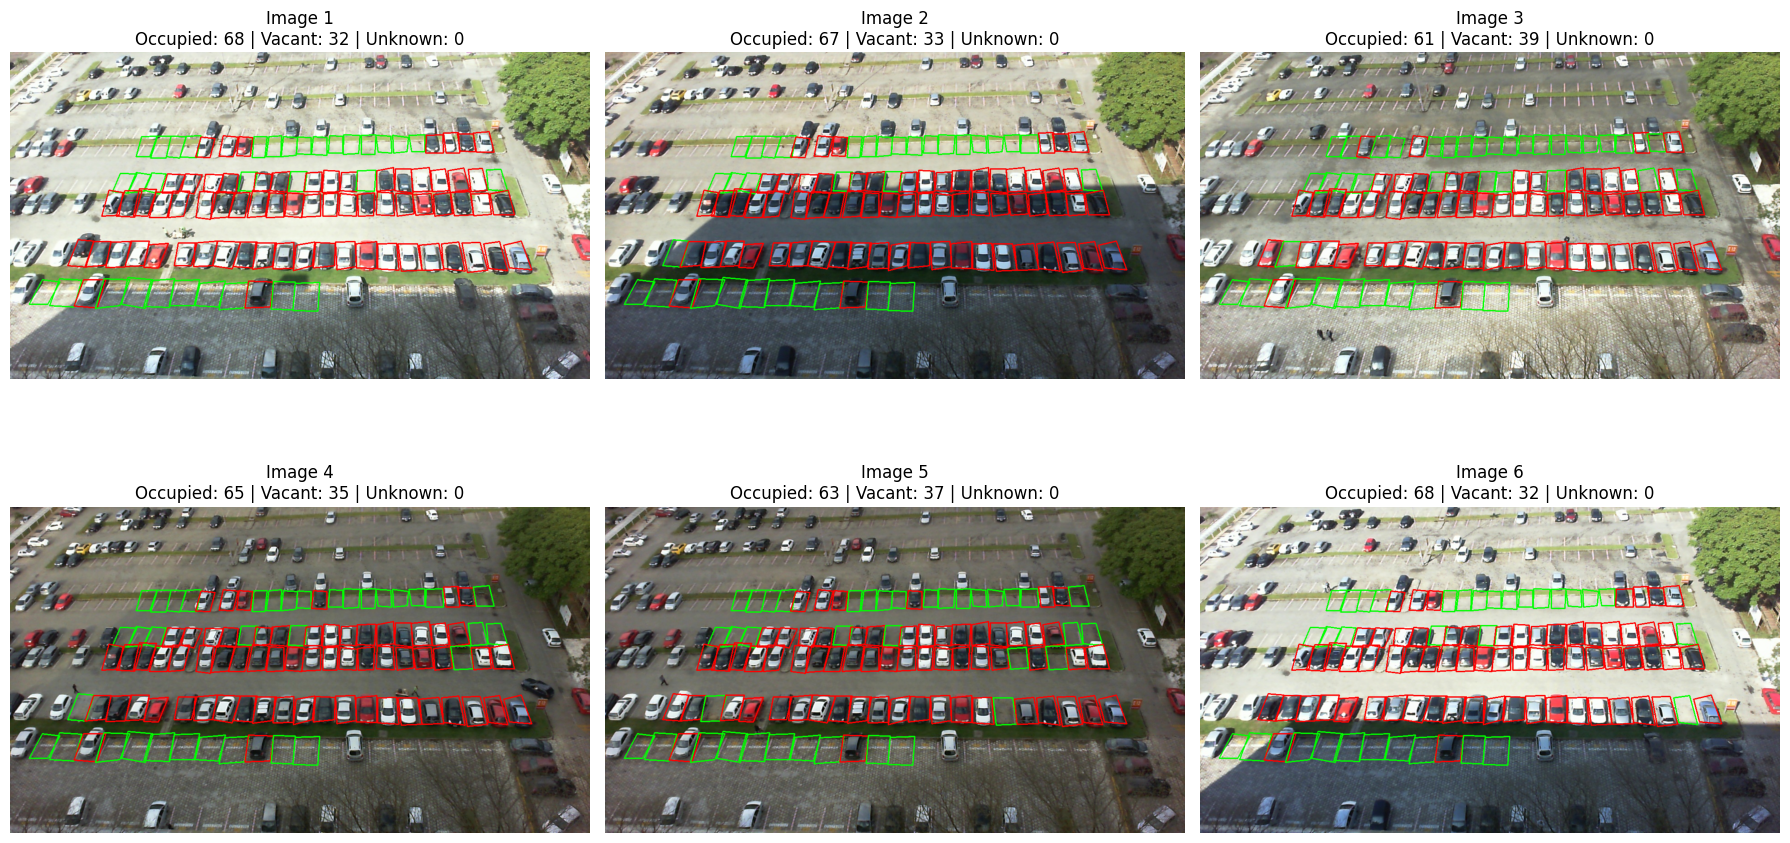

Visualization saved:
data/processed/parking_annotations.png


In [28]:
# ============================================================
# STEP 9: VISUALIZE PARKING-SPACE ANNOTATIONS
# ============================================================

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Number of images to display
NUM_IMAGES = 6

# Select samples
visual_samples = samples[:NUM_IMAGES]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for idx, sample in enumerate(visual_samples):

    image_path = find_image(sample["filepath"])

    image = cv2.imread(image_path)

    if image is None:
        axes[idx].axis("off")
        continue

    # Convert BGR -> RGB
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    height, width = image.shape[:2]

    # Draw every parking space
    parking_spaces = sample.get(
        "parking_spaces",
        {}
    )

    polylines = parking_spaces.get(
        "polylines",
        []
    )

    occupied = 0
    vacant = 0
    unknown = 0

    for space in polylines:

        if space.get("label") != "parking_space":
            continue

        status = str(
            space.get(
                "occupancy_status",
                ""
            )
        ).lower().strip()

        points = space.get("points")

        if not points:
            continue

        try:

            polygon_points = points[0]

            polygon = np.array(
                polygon_points,
                dtype=np.float32
            )

            if (
                polygon.ndim != 2
                or polygon.shape[1] != 2
            ):
                continue

            # Normalized -> pixels
            polygon[:, 0] *= width
            polygon[:, 1] *= height

            polygon = polygon.astype(
                np.int32
            )

            # Count classes
            if status == "occupied":
                occupied += 1

            elif status == "not occupied":
                vacant += 1

            elif status == "unknown":
                unknown += 1

            # Draw polygon
            cv2.polylines(
                image_rgb,
                [polygon],
                isClosed=True,
                color=(
                    255, 0, 0
                ) if status == "occupied"
                else (
                    0, 255, 0
                ) if status == "not occupied"
                else (
                    255, 255, 0
                ),
                thickness=2
            )

        except Exception:
            continue

    # Display
    axes[idx].imshow(image_rgb)

    axes[idx].set_title(
        f"Image {idx + 1}\n"
        f"Occupied: {occupied} | "
        f"Vacant: {vacant} | "
        f"Unknown: {unknown}"
    )

    axes[idx].axis("off")


plt.tight_layout()

# Save visualization
plt.savefig(
    "data/processed/parking_annotations.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Visualization saved:")
print("data/processed/parking_annotations.png")

In [29]:
X_train = []
for path in train_df["path"]:
    ...
X_train = np.array(X_train)

In [31]:
# ============================================================
# STEP 9: CV BASELINE VISUALIZATION
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

NUM_IMAGES_TO_PROCESS = 10

output_dir = "outputs/cv_baseline"
os.makedirs(output_dir, exist_ok=True)

processed = 0

# ------------------------------------------------------------
# Process samples from samples.json
# ------------------------------------------------------------

for sample_idx, sample in enumerate(samples):

    if processed >= NUM_IMAGES_TO_PROCESS:
        break

    # Find image
    image_path = find_image(sample["filepath"])

    if image_path is None:
        continue

    img = cv2.imread(image_path)

    if img is None:
        continue

    h_img, w_img = img.shape[:2]

    # --------------------------------------------------------
    # Get parking-space annotations
    # --------------------------------------------------------

    parking_spaces = sample.get(
        "parking_spaces",
        {}
    )

    polylines = parking_spaces.get(
        "polylines",
        []
    )

    if not polylines:
        continue

    occupied_count = 0
    vacant_count = 0
    unknown_count = 0

    # --------------------------------------------------------
    # Draw every parking-space polygon
    # --------------------------------------------------------

    for space in polylines:

        if space.get("label") != "parking_space":
            continue

        status = str(
            space.get(
                "occupancy_status",
                ""
            )
        ).lower().strip()

        points = space.get("points")

        if not points:
            continue

        try:

            # PKLot format:
            # points = [[[x1,y1], [x2,y2], ...]]

            polygon_points = points[0]

            polygon = np.array(
                polygon_points,
                dtype=np.float32
            )

            if (
                polygon.ndim != 2
                or polygon.shape[1] != 2
                or polygon.shape[0] < 3
            ):
                continue

            # Normalized coordinates -> pixels
            polygon[:, 0] *= w_img
            polygon[:, 1] *= h_img

            polygon = polygon.astype(
                np.int32
            )

        except Exception:
            continue

        # ----------------------------------------------------
        # Determine color/class
        # ----------------------------------------------------

        if status == "occupied":

            color = (0, 0, 255)       # Red
            occupied_count += 1

        elif status == "not occupied":

            color = (0, 255, 0)       # Green
            vacant_count += 1

        elif status == "unknown":

            color = (0, 255, 255)     # Yellow
            unknown_count += 1

        else:
            continue

        # ----------------------------------------------------
        # Draw polygon
        # ----------------------------------------------------

        cv2.polylines(
            img,
            [polygon],
            isClosed=True,
            color=color,
            thickness=2
        )

    # --------------------------------------------------------
    # Calculate occupancy
    # --------------------------------------------------------

    total = occupied_count + vacant_count

    if total == 0:
        continue

    occupancy_percentage = (
        100 * occupied_count / total
    )

    caption = (
        f"Occupied: {occupied_count} | "
        f"Vacant: {vacant_count} | "
        f"Unknown: {unknown_count} | "
        f"{occupancy_percentage:.1f}% Full"
    )

    # --------------------------------------------------------
    # Add caption
    # --------------------------------------------------------

    cv2.rectangle(
        img,
        (5, 5),
        (min(w_img - 5, 850), 45),
        (0, 0, 0),
        -1
    )

    cv2.putText(
        img,
        caption,
        (15, 32),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

    # --------------------------------------------------------
    # Save image
    # --------------------------------------------------------

    base_name = os.path.splitext(
        os.path.basename(image_path)
    )[0]

    output_path = os.path.join(
        output_dir,
        f"{base_name}_annotated.jpg"
    )

    cv2.imwrite(
        output_path,
        img
    )

    print(
        f"{base_name}: {caption}"
    )

    processed += 1


# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print()
print("=" * 60)
print("CV VISUALIZATION COMPLETE")
print("=" * 60)
print(f"Processed: {processed} images")
print(f"Saved to: {output_dir}/")

2012-09-21_14_45_32: Occupied: 68 | Vacant: 32 | Unknown: 0 | 68.0% Full
2012-09-21_15_30_34: Occupied: 67 | Vacant: 33 | Unknown: 0 | 67.0% Full
2012-09-21_14_10_30: Occupied: 61 | Vacant: 39 | Unknown: 0 | 61.0% Full
2012-09-21_16_25_36: Occupied: 65 | Vacant: 35 | Unknown: 0 | 65.0% Full
2012-09-21_16_35_37: Occupied: 63 | Vacant: 37 | Unknown: 0 | 63.0% Full
2012-09-21_14_55_32: Occupied: 68 | Vacant: 32 | Unknown: 0 | 68.0% Full
2012-09-21_15_20_34: Occupied: 67 | Vacant: 33 | Unknown: 0 | 67.0% Full
2012-09-21_15_10_33: Occupied: 66 | Vacant: 34 | Unknown: 0 | 66.0% Full
2012-09-21_14_20_31: Occupied: 64 | Vacant: 36 | Unknown: 0 | 64.0% Full
2012-09-21_16_40_37: Occupied: 62 | Vacant: 38 | Unknown: 0 | 62.0% Full

CV VISUALIZATION COMPLETE
Processed: 10 images
Saved to: outputs/cv_baseline/


In [35]:
# ============================================================
# STEP 9: CV BASELINE VISUALIZATION
# ============================================================

import os
import cv2
import numpy as np

NUM_IMAGES_TO_PROCESS = 10

output_dir = "outputs/cv_baseline"
os.makedirs(output_dir, exist_ok=True)

processed = 0

for sample in samples:

    if processed >= NUM_IMAGES_TO_PROCESS:
        break

    # --------------------------------------------------------
    # Find image
    # --------------------------------------------------------

    image_path = find_image(sample["filepath"])

    if image_path is None:
        continue

    img = cv2.imread(image_path)

    if img is None:
        continue

    h_img, w_img = img.shape[:2]

    # --------------------------------------------------------
    # Get parking-space annotations
    # --------------------------------------------------------

    parking_spaces = sample.get(
        "parking_spaces",
        {}
    )

    polylines = parking_spaces.get(
        "polylines",
        []
    )

    if not polylines:
        continue

    occupied_count = 0
    vacant_count = 0
    unknown_count = 0

    # --------------------------------------------------------
    # Draw parking spaces
    # --------------------------------------------------------

    for space in polylines:

        if space.get("label") != "parking_space":
            continue

        status = str(
            space.get(
                "occupancy_status",
                ""
            )
        ).lower().strip()

        points = space.get("points")

        if not points:
            continue

        try:

            polygon_points = points[0]

            polygon = np.array(
                polygon_points,
                dtype=np.float32
            )

            if polygon.ndim != 2:
                continue

            if polygon.shape[1] != 2:
                continue

            if polygon.shape[0] < 3:
                continue

            # Normalized coordinates → pixels
            polygon[:, 0] *= w_img
            polygon[:, 1] *= h_img

            polygon = polygon.astype(np.int32)

        except Exception:
            continue

        # ----------------------------------------------------
        # Class and color
        # ----------------------------------------------------

        if status == "occupied":

            color = (0, 0, 255)
            occupied_count += 1

        elif status == "not occupied":

            color = (0, 255, 0)
            vacant_count += 1

        elif status == "unknown":

            color = (0, 255, 255)
            unknown_count += 1

        else:
            continue

        # ----------------------------------------------------
        # Draw polygon
        # ----------------------------------------------------

        cv2.polylines(
            img,
            [polygon],
            True,
            color,
            2
        )

    # --------------------------------------------------------
    # Occupancy percentage
    # --------------------------------------------------------

    total = occupied_count + vacant_count

    if total == 0:
        continue

    percentage = (
        occupied_count / total
    ) * 100

    caption = (
        f"Occupied: {occupied_count} | "
        f"Vacant: {vacant_count} | "
        f"Unknown: {unknown_count} | "
        f"{percentage:.1f}% Full"
    )

    # --------------------------------------------------------
    # Caption background
    # --------------------------------------------------------

    cv2.rectangle(
        img,
        (5, 5),
        (min(w_img - 5, 900), 45),
        (0, 0, 0),
        -1
    )

    cv2.putText(
        img,
        caption,
        (15, 32),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    base_name = os.path.splitext(
        os.path.basename(image_path)
    )[0]

    output_path = os.path.join(
        output_dir,
        f"{base_name}_annotated.jpg"
    )

    cv2.imwrite(
        output_path,
        img
    )

    print(
        f"{base_name}: {caption}"
    )

    processed += 1


print()
print("=" * 60)
print("CV VISUALIZATION COMPLETE")
print("=" * 60)

print("Processed:", processed)
print("Output folder:", output_dir)

2012-09-21_14_45_32: Occupied: 68 | Vacant: 32 | Unknown: 0 | 68.0% Full
2012-09-21_15_30_34: Occupied: 67 | Vacant: 33 | Unknown: 0 | 67.0% Full
2012-09-21_14_10_30: Occupied: 61 | Vacant: 39 | Unknown: 0 | 61.0% Full
2012-09-21_16_25_36: Occupied: 65 | Vacant: 35 | Unknown: 0 | 65.0% Full
2012-09-21_16_35_37: Occupied: 63 | Vacant: 37 | Unknown: 0 | 63.0% Full
2012-09-21_14_55_32: Occupied: 68 | Vacant: 32 | Unknown: 0 | 68.0% Full
2012-09-21_15_20_34: Occupied: 67 | Vacant: 33 | Unknown: 0 | 67.0% Full
2012-09-21_15_10_33: Occupied: 66 | Vacant: 34 | Unknown: 0 | 66.0% Full
2012-09-21_14_20_31: Occupied: 64 | Vacant: 36 | Unknown: 0 | 64.0% Full
2012-09-21_16_40_37: Occupied: 62 | Vacant: 38 | Unknown: 0 | 62.0% Full

CV VISUALIZATION COMPLETE
Processed: 10
Output folder: outputs/cv_baseline


In [38]:
# ============================================================
# STEP 9: CV BASELINE VISUALIZATION
# ============================================================

import os
import cv2
import numpy as np

NUM_IMAGES_TO_PROCESS = 10

output_dir = "outputs/cv_baseline"
os.makedirs(output_dir, exist_ok=True)

processed = 0

for sample in samples:

    if processed >= NUM_IMAGES_TO_PROCESS:
        break

    # Find image
    image_path = find_image(sample["filepath"])

    if image_path is None:
        continue

    img = cv2.imread(image_path)

    if img is None:
        continue

    h_img, w_img = img.shape[:2]

    # Get parking spaces
    parking_spaces = sample.get("parking_spaces", {})
    polylines = parking_spaces.get("polylines", [])

    if not polylines:
        continue

    occupied_count = 0
    vacant_count = 0
    unknown_count = 0

    # Draw parking spaces
    for space in polylines:

        if space.get("label") != "parking_space":
            continue

        status = str(
            space.get("occupancy_status", "")
        ).lower().strip()

        points = space.get("points")

        if not points:
            continue

        try:
            polygon = np.array(
                points[0],
                dtype=np.float32
            )

            if polygon.ndim != 2:
                continue

            if polygon.shape[1] != 2:
                continue

            if polygon.shape[0] < 3:
                continue

            # Normalized coordinates → pixels
            polygon[:, 0] *= w_img
            polygon[:, 1] *= h_img

            polygon = polygon.astype(np.int32)

        except Exception:
            continue

        # Colors:
        # Red    = occupied
        # Green  = not occupied
        # Yellow = unknown

        if status == "occupied":
            color = (0, 0, 255)
            occupied_count += 1

        elif status == "not occupied":
            color = (0, 255, 0)
            vacant_count += 1

        elif status == "unknown":
            color = (0, 255, 255)
            unknown_count += 1

        else:
            continue

        cv2.polylines(
            img,
            [polygon],
            True,
            color,
            2
        )

    # Calculate occupancy
    total = occupied_count + vacant_count

    if total == 0:
        continue

    percentage = (
        occupied_count / total
    ) * 100

    caption = (
        f"Occupied: {occupied_count} | "
        f"Vacant: {vacant_count} | "
        f"Unknown: {unknown_count} | "
        f"{percentage:.1f}% Full"
    )

    # Caption background
    cv2.rectangle(
        img,
        (5, 5),
        (min(w_img - 5, 900), 45),
        (0, 0, 0),
        -1
    )

    cv2.putText(
        img,
        caption,
        (15, 32),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

    # Save
    base_name = os.path.splitext(
        os.path.basename(image_path)
    )[0]

    output_path = os.path.join(
        output_dir,
        f"{base_name}_annotated.jpg"
    )

    cv2.imwrite(output_path, img)

    print(f"{base_name}: {caption}")

    processed += 1


print()
print("=" * 60)
print("CV VISUALIZATION COMPLETE")
print("=" * 60)
print("Processed:", processed)
print("Output folder:", output_dir)

2012-09-21_14_45_32: Occupied: 68 | Vacant: 32 | Unknown: 0 | 68.0% Full
2012-09-21_15_30_34: Occupied: 67 | Vacant: 33 | Unknown: 0 | 67.0% Full
2012-09-21_14_10_30: Occupied: 61 | Vacant: 39 | Unknown: 0 | 61.0% Full
2012-09-21_16_25_36: Occupied: 65 | Vacant: 35 | Unknown: 0 | 65.0% Full
2012-09-21_16_35_37: Occupied: 63 | Vacant: 37 | Unknown: 0 | 63.0% Full
2012-09-21_14_55_32: Occupied: 68 | Vacant: 32 | Unknown: 0 | 68.0% Full
2012-09-21_15_20_34: Occupied: 67 | Vacant: 33 | Unknown: 0 | 67.0% Full
2012-09-21_15_10_33: Occupied: 66 | Vacant: 34 | Unknown: 0 | 66.0% Full
2012-09-21_14_20_31: Occupied: 64 | Vacant: 36 | Unknown: 0 | 64.0% Full
2012-09-21_16_40_37: Occupied: 62 | Vacant: 38 | Unknown: 0 | 62.0% Full

CV VISUALIZATION COMPLETE
Processed: 10
Output folder: outputs/cv_baseline


TensorFlow version: 2.20.0
Total records: 686084

Split distribution:
split
train         480258
validation    102913
test          102913
Name: count, dtype: int64

Class distribution:
label
vacant      350349
occupied    335735
Name: count, dtype: int64
train: 480258 images
validation: 102913 images
test: 102913 images


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,273 (2.47 MB)

 Trainable params: 646,273 (2.47 MB)

 Non-trainable params: 0 (0.00 B)



STARTING CNN TRAINING
Epoch 1/15
7505/7505 ━━━━━━━━━━━━━━━━━━━━ 282s 37ms/step - accuracy: 0.9945 - loss: 0.0209 - val_accuracy: 0.9946 - val_loss: 0.0187
Epoch 2/15
7505/7505 ━━━━━━━━━━━━━━━━━━━━ 179s 24ms/step - accuracy: 0.9980 - loss: 0.0102 - val_accuracy: 0.9984 - val_loss: 0.0086
Epoch 3/15
7505/7505 ━━━━━━━━━━━━━━━━━━━━ 134s 18ms/step - accuracy: 0.9986 - loss: 0.0078 - val_accuracy: 0.9986 - val_loss: 0.0075
Epoch 4/15
7505/7505 ━━━━━━━━━━━━━━━━━━━━ 109s 14ms/step - accuracy: 0.9987 - loss: 0.0071 - val_accuracy: 0.9989 - val_loss: 0.0069
Epoch 5/15
7505/7505 ━━━━━━━━━━━━━━━━━━━━ 104s 14ms/step - accuracy: 0.9988 - loss: 0.0063 - val_accuracy: 0.9990 - val_loss: 0.0067
Epoch 6/15
7505/7505 ━━━━━━━━━━━━━━━━━━━━ 133s 13ms/step - accuracy: 0.9989 - loss: 0.0057 - val_accuracy: 0.9990 - val_loss: 0.0075
Epoch 7/15
7505/7505 ━━━━━━━━━━━━━━━━━━━━ 99s 13ms/step - accuracy: 0.9989 - loss: 0.0056 - val_accuracy: 0.9991 - val_loss: 0.0081
Epoch 8/15
7505/7505 ━━━━━━━━━━━━━━━━━━━━ 100s

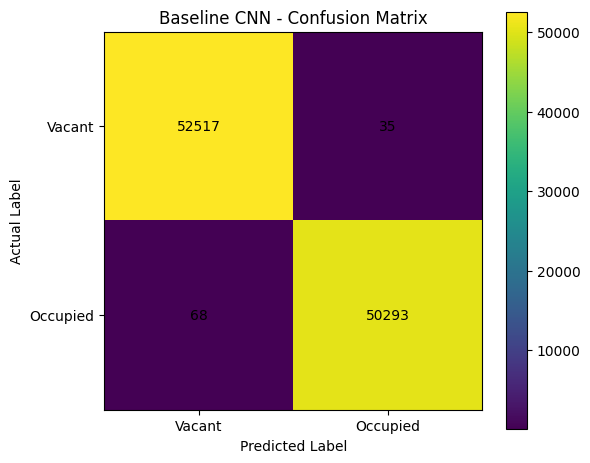

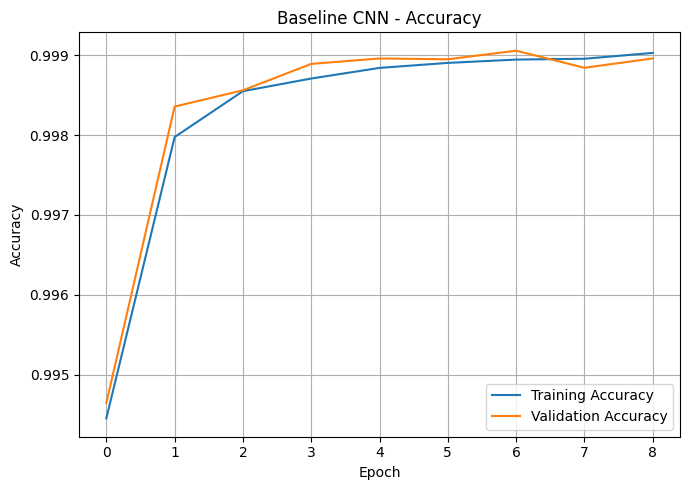

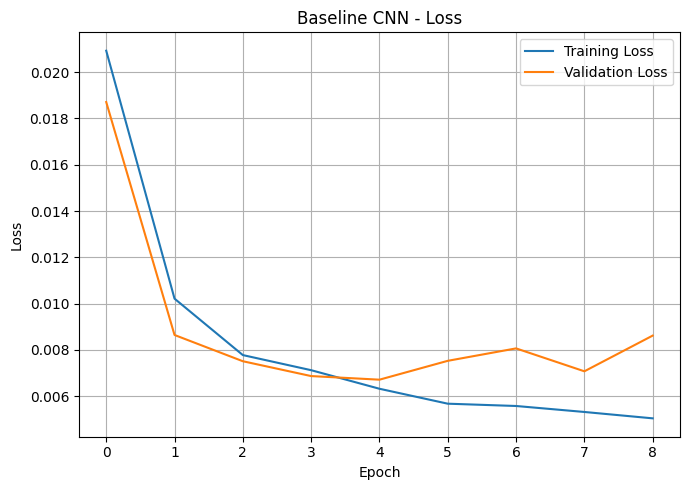



CNN TRAINING COMPLETE
Model saved: models/baseline_cnn.keras
Metrics saved: results/dl_baseline_metrics.txt
Confusion matrix saved: results/dl_baseline_confusion_matrix.png
Accuracy curve saved: results/dl_baseline_accuracy.png
Loss curve saved: results/dl_baseline_loss.png


In [39]:
# ============================================================
# STEP 10: BASELINE CNN
# MEMORY-SAFE VERSION
# ============================================================

import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

IMG_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 15

print("TensorFlow version:", tf.__version__)

# ------------------------------------------------------------
# 2. Create output folders
# ------------------------------------------------------------

os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

# ------------------------------------------------------------
# 3. Load split information
# ------------------------------------------------------------

splits = pd.read_csv(
    "data/processed/splits.csv"
)

label_map = {
    "vacant": 0,
    "occupied": 1
}

print("Total records:", len(splits))
print("\nSplit distribution:")
print(splits["split"].value_counts())

print("\nClass distribution:")
print(splits["label"].value_counts())


# ============================================================
# 4. Create TensorFlow dataset
# ============================================================

def create_dataset(split_name, shuffle=False):

    subset = splits[
        splits["split"] == split_name
    ].copy()

    paths = subset["path"].values

    labels = np.array([
        label_map[label]
        for label in subset["label"]
    ], dtype=np.float32)

    print(
        f"{split_name}: "
        f"{len(paths)} images"
    )

    # --------------------------------------------------------
    # TensorFlow dataset
    # --------------------------------------------------------

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    # Shuffle training data only
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=10000,
            reshuffle_each_iteration=True
        )

    # --------------------------------------------------------
    # Read image
    # --------------------------------------------------------

    def load_image(path, label):

        image = tf.io.read_file(path)

        image = tf.image.decode_jpeg(
            image,
            channels=3
        )

        image = tf.image.resize(
            image,
            [IMG_SIZE, IMG_SIZE]
        )

        # Convert 0-255 -> 0-1
        image = tf.cast(
            image,
            tf.float32
        ) / 255.0

        return image, label

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


# ============================================================
# 5. Create train / validation / test datasets
# ============================================================

train_ds = create_dataset(
    "train",
    shuffle=True
)

val_ds = create_dataset(
    "validation",
    shuffle=False
)

test_ds = create_dataset(
    "test",
    shuffle=False
)


# ============================================================
# 6. Build CNN
# ============================================================

model = models.Sequential([

    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    # Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 3
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Classification
    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(0.4),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])


# ============================================================
# 7. Compile model
# ============================================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 8. Display model
# ============================================================

model.summary()


# ============================================================
# 9. Early stopping
# ============================================================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)


# ============================================================
# 10. Train CNN
# ============================================================

print("\n")
print("=" * 60)
print("STARTING CNN TRAINING")
print("=" * 60)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


# ============================================================
# 11. Evaluate on test set
# ============================================================

print("\n")
print("=" * 60)
print("TEST EVALUATION")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(
    test_ds
)

print(
    f"\nTest Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)


# ============================================================
# 12. Predictions
# ============================================================

print("\nGenerating predictions...")

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predictions = (
        predictions.ravel() >= 0.5
    ).astype(int)

    y_pred.extend(
        predictions
    )

    y_true.extend(
        labels.numpy().astype(int)
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ============================================================
# 13. Classification report
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=[
        "vacant",
        "occupied"
    ]
)

print("\n")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(report)


# ============================================================
# 14. Save metrics
# ============================================================

with open(
    "results/dl_baseline_metrics.txt",
    "w"
) as f:

    f.write(
        f"Test Loss: {test_loss:.4f}\n"
    )

    f.write(
        f"Test Accuracy: "
        f"{test_accuracy:.4f}\n\n"
    )

    f.write(report)


# ============================================================
# 15. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


plt.figure(
    figsize=(6, 5)
)

plt.imshow(cm)

plt.title(
    "Baseline CNN - Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Vacant", "Occupied"]
)

plt.yticks(
    [0, 1],
    ["Vacant", "Occupied"]
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

# Write values inside matrix
for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "results/dl_baseline_confusion_matrix.png",
    dpi=150
)

plt.show()


# ============================================================
# 16. Training Accuracy Curve
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Baseline CNN - Accuracy"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "results/dl_baseline_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# 17. Training Loss Curve
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Baseline CNN - Loss"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "results/dl_baseline_loss.png",
    dpi=150
)

plt.show()


# ============================================================
# 18. Save CNN model
# ============================================================

model.save(
    "models/baseline_cnn.keras"
)

print("\n")
print("=" * 60)
print("CNN TRAINING COMPLETE")
print("=" * 60)

print(
    "Model saved: "
    "models/baseline_cnn.keras"
)

print(
    "Metrics saved: "
    "results/dl_baseline_metrics.txt"
)

print(
    "Confusion matrix saved: "
    "results/dl_baseline_confusion_matrix.png"
)

print(
    "Accuracy curve saved: "
    "results/dl_baseline_accuracy.png"
)

print(
    "Loss curve saved: "
    "results/dl_baseline_loss.png"
)